# Comparación estadística de los modelos

Una diferencia de una milésima de AUC entre dos modelos no significa nada si la variabilidad de
la estimación es de cinco milésimas. Esta página aplica el protocolo de la guía (§6) para decidir
qué diferencias son reales:

| Tarea | Paso 1: ¿difieren? | Paso 2: ¿cuáles? | Paso 3: finalistas sobre la prueba | Tamaño del efecto |
|---|---|---|---|---|
| Clasificación | Friedman (con Iman-Davenport) | Nemenyi y diagrama de diferencia crítica | DeLong por pares con Holm y Benjamini-Hochberg | delta de Cliff |
| Regresión | *Model Confidence Set* | Giacomini-White condicional | Diebold-Mariano con HLN y bootstrap estacionario | d de Cohen |

En las dos tareas cada modelo entra con **su mejor combinación de balanceo y optimizador según el
bucle externo**, elegida sin mirar la prueba. Los pasos 1 y 2 usan los puntajes de los 5 pliegues
externos, que son los mismos para todos los modelos; el paso 3 usa la prueba (9.745 clientes), que
cada modelo ve una sola vez. Las métricas principales llevan intervalos bootstrap BCa.

In [1]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import analisis, comparacion, datos, graficos
from src import estadistica as est
from src.analisis import NOMBRES_MODELO
from src.formato import dec, ent, enumerar, intervalo, p_valor, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

tabla = analisis.cargar_tabla()
p = datos.preparar_todo()                      # etiqueta del percentil 75, la de las corridas
X_te = p['conjuntos'].X_test.sort_index()      # orden original del archivo de clientes
y_te = p['y_test'].loc[X_te.index]
y_te_c = p['conjuntos'].y_test_cont.loc[X_te.index]
pred = analisis.predecir_prueba(tabla, X_te, RAIZ / 'resultados' / 'predicciones_prueba.parquet',
                                informar=lambda s: None)
mejores = {t: analisis.mejores_por_modelo(tabla, t) for t in ('clasificacion', 'regresion')}
for t, m in mejores.items():
    print(t)
    print(m[['modelo', 'balanceo', 'optimizador', 'metrica', 'desv_ext']].to_string(index=False))

clasificacion
       modelo     balanceo optimizador  metrica  desv_ext
      xgboost class_weight    genetica   0.8332    0.0049
        arbol class_weight      random   0.8332    0.0021
random_forest      ninguno    genetica   0.8326    0.0029
          ebm class_weight        grid   0.8292    0.0037
          knn      ninguno    genetica   0.7836    0.0072
    logistica class_weight    genetica   0.7644    0.0047
          svm class_weight        grid   0.7641    0.0044
  naive_bayes      ninguno        grid   0.6722    0.0119
regresion
       modelo balanceo optimizador  metrica  desv_ext
      xgboost  ninguno   bayesiana   0.0590    0.0004
          ebm  ninguno        grid   0.0590    0.0004
random_forest  ninguno        grid   0.0592    0.0004
        arbol  ninguno    genetica   0.0593    0.0004
        lasso  ninguno    genetica   0.0618    0.0005
        ridge  ninguno    genetica   0.0618    0.0005
          svr  ninguno   bayesiana   0.0618    0.0005
          knn  ninguno

## Clasificación

### Paso 1 y 2: Friedman y Nemenyi sobre los pliegues externos

Cada pliegue externo es un bloque en el que los modelos se ordenan por su AUC. Con 5 bloques la
prueba tiene poca potencia (la diferencia crítica de Nemenyi es grande), así que se repite con un
diseño más amplio como comprobación de robustez: cada combinación de pliegue, balanceo y
optimizador es un bloque, de modo que un modelo se compara con los demás en las mismas condiciones.
Esos bloques no son independientes (comparten datos), y por eso el diseño principal es el de 5.

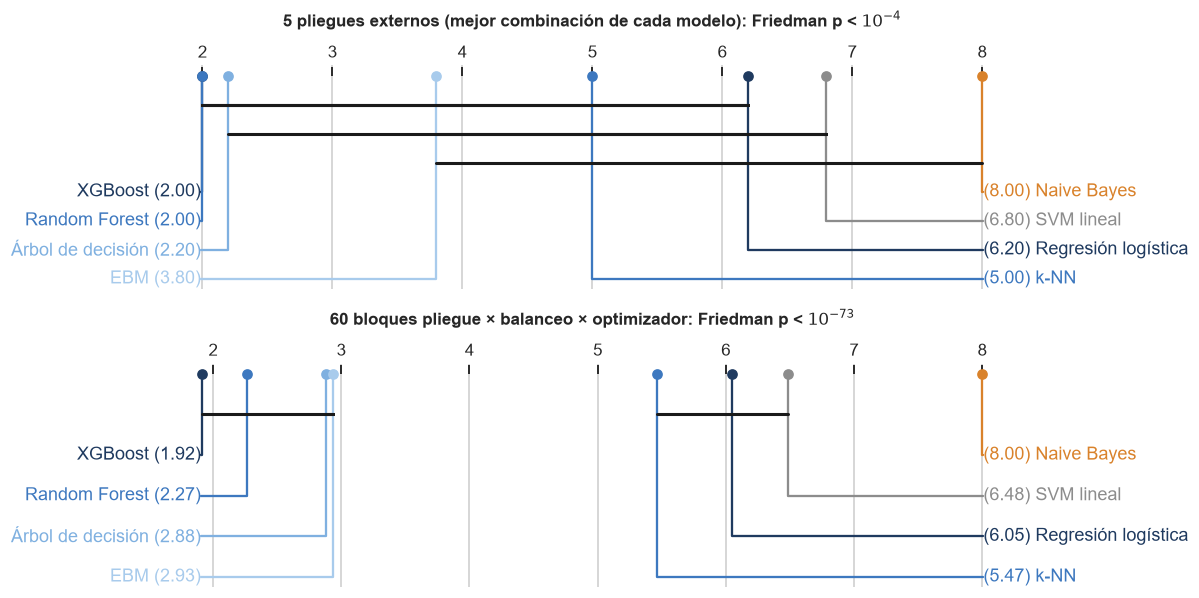

,5 pliegues,bloques amplios
n_bloques,5.0000,60.0000
k,8.0000,8.0000
chi2,32.4667,362.5000
p,0.0000,0.0000
F,51.2632,371.9565
p_iman_davenport,0.0000,0.0000
dc,4.6954,1.3555


In [2]:
def puntajes_por_pliegue(mej):
    return pd.DataFrame({f['modelo']: f['puntajes_ext'] for _, f in mej.iterrows()})

auc_pliegues = puntajes_por_pliegue(mejores['clasificacion'])
fr_c = est.friedman(auc_pliegues)

ok = tabla[(tabla['tarea'] == 'clasificacion') & (tabla['estado'] == 'ok')]
largo = []
for _, f in ok.iterrows():
    for i, v in enumerate(f['puntajes_ext']):
        largo.append({'bloque': (f['balanceo'], f['optimizador'], i), 'modelo': f['modelo'], 'auc': v})
amplio = pd.DataFrame(largo).pivot_table(index='bloque', columns='modelo', values='auc')
fr_amplio = est.friedman(amplio)

fig, ax = plt.subplots(2, 1, figsize=(11, 5.6))
graficos.diagrama_cd(fr_c, ax=ax[0], etiquetas=NOMBRES_MODELO,
                     titulo=f'5 pliegues externos (mejor combinación de cada modelo): Friedman {p_valor(fr_c["p"], grafico=True)}')
graficos.diagrama_cd(fr_amplio, ax=ax[1], etiquetas=NOMBRES_MODELO,
                     titulo=f'{fr_amplio["n_bloques"]} bloques pliegue × balanceo × optimizador: Friedman {p_valor(fr_amplio["p"], grafico=True)}')
plt.tight_layout()
plt.show()
pd.DataFrame({'5 pliegues': {k: fr_c[k] for k in ('n_bloques', 'k', 'chi2', 'p', 'F', 'p_iman_davenport', 'dc')},
              'bloques amplios': {k: fr_amplio[k] for k in ('n_bloques', 'k', 'chi2', 'p', 'F', 'p_iman_davenport', 'dc')}})

In [3]:
rangos = fr_c['rangos_medios']
mejor_modelo = rangos.index[0]
indistinguibles = [m for m in rangos.index if fr_c['p_nemenyi'].loc[mejor_modelo, m] >= 0.05]
display(Markdown(f"""
Con los 5 pliegues externos los modelos difieren (Friedman {p_valor(fr_c['p'])}; Iman-Davenport
{p_valor(fr_c['p_iman_davenport'])}), pero la diferencia crítica de Nemenyi es de {dec(fr_c['dc'], 2)} rangos
sobre {fr_c['k']} modelos, y solo los extremos se separan: {NOMBRES_MODELO[mejor_modelo]}, el de mejor
rango medio, no se distingue de {enumerar(NOMBRES_MODELO[m] for m in indistinguibles if m != mejor_modelo)}.
Con {fr_amplio['n_bloques']} bloques la diferencia crítica baja a {dec(fr_amplio['dc'], 2)} rangos y el orden es
el mismo: {', '.join(f"{NOMBRES_MODELO[m]} ({dec(v, 2)})" for m, v in fr_amplio['rangos_medios'].items())}.
"""))


Con los 5 pliegues externos los modelos difieren (Friedman p < 10⁻⁴; Iman-Davenport
p < 10⁻¹³), pero la diferencia crítica de Nemenyi es de 4,70 rangos
sobre 8 modelos, y solo los extremos se separan: XGBoost, el de mejor
rango medio, no se distingue de Random Forest, Árbol de decisión, EBM, k-NN y Regresión logística.
Con 60 bloques la diferencia crítica baja a 1,36 rangos y el orden es
el mismo: XGBoost (1,92), Random Forest (2,27), Árbol de decisión (2,88), EBM (2,93), k-NN (5,47), Regresión logística (6,05), SVM lineal (6,48), Naive Bayes (8,00).


### Paso 3: DeLong entre los finalistas, sobre la prueba

Los finalistas son los modelos que Nemenyi no separa del mejor en el diseño amplio, más el modelo
nuevo. Sobre la prueba, DeLong compara cada pareja teniendo en cuenta que las dos AUC se calculan
sobre los mismos clientes (y por eso están correlacionadas). Con varias parejas a la vez, los
p-valores se ajustan con Holm-Bonferroni (controla la probabilidad de algún falso positivo) y con
Benjamini-Hochberg (controla la proporción de falsos descubrimientos).

In [4]:
rangos_amplio = fr_amplio['rangos_medios']
lider = rangos_amplio.index[0]
finalistas = [m for m in rangos_amplio.index if fr_amplio['p_nemenyi'].loc[lider, m] >= 0.05]
if 'ebm' in auc_pliegues.columns and 'ebm' not in finalistas:
    finalistas.append('ebm')
claves = mejores['clasificacion'].set_index('modelo')['clave']
puntajes = {m: pred[claves[m]].to_numpy() for m in finalistas}
pares = [(a, b) for i, a in enumerate(finalistas) for b in finalistas[i + 1:]]
delong = comparacion.contrastar_clasificacion(y_te, puntajes, pares, auc_pliegues={m: auc_pliegues[m] for m in finalistas})
delong['p_bh'] = est.ajustar_pvalores(delong['p_delong'], 'fdr_bh')
delong[['referencia', 'candidato', 'auc_referencia', 'auc_candidato', 'diferencia', 'ic_bca_inf', 'ic_bca_sup',
        'p_delong', 'p_delong_ajustado', 'p_bh', 'correlacion_auc', 'delta_cliff', 'magnitud_cliff']]

,referencia,candidato,auc_referencia,auc_candidato,diferencia,ic_bca_inf,ic_bca_sup,p_delong,p_delong_ajustado,p_bh,correlacion_auc,delta_cliff,magnitud_cliff
0,xgboost,random_forest,0.8283,0.8260,-0.0023,-0.0071,0.0029,0.3638,1.0000,0.5524,0.8077,-0.2000,pequeño
1,xgboost,arbol,0.8283,0.8243,-0.0040,-0.0083,0.0002,0.0795,0.4773,0.4773,0.8403,-0.1200,despreciable
2,xgboost,ebm,0.8283,0.8289,0.0006,-0.0057,0.0071,0.8479,1.0000,0.8479,0.6594,-0.5200,grande
3,random_forest,arbol,0.8260,0.8243,-0.0017,-0.0074,0.0041,0.5697,1.0000,0.6837,0.7195,0.1200,despreciable
4,random_forest,ebm,0.8260,0.8289,0.0029,-0.0035,0.0093,0.3683,1.0000,0.5524,0.6788,-0.4400,mediano
5,arbol,ebm,0.8243,0.8289,0.0046,-0.0019,0.0116,0.2066,1.0000,0.5524,0.5863,-0.6800,grande


In [5]:
intervalos_clf = comparacion.intervalos_clasificacion(y_te, {m: pred[claves[m]].to_numpy() for m in claves.index})
intervalos_clf.index = [NOMBRES_MODELO[m] for m in intervalos_clf.index]
intervalos_clf.sort_values('auc', ascending=False)

,auc,ee_delong,ic_delong_inf,ic_delong_sup,ic_bca_inf,ic_bca_sup
EBM,0.8289,0.0040,0.8210,0.8368,0.8206,0.8366
XGBoost,0.8283,0.0040,0.8204,0.8362,0.8203,0.8359
Random Forest,0.8260,0.0040,0.8181,0.8339,0.8184,0.8338
Árbol de decisión,0.8243,0.0040,0.8164,0.8322,0.8165,0.8319
k-NN,0.7874,0.0048,0.7779,0.7968,0.7777,0.7966
Regresión logística,0.7709,0.0051,0.7608,0.7809,0.7600,0.7806
SVM lineal,0.7706,0.0051,0.7605,0.7806,0.7599,0.7803
Naive Bayes,0.6662,0.0063,0.6540,0.6785,0.6537,0.6787


In [6]:
sig = delong[delong['p_delong_ajustado'] < 0.05]
if len(sig) == 0:
    frase_holm = '**ninguna diferencia sobrevive** a la corrección de Holm'
else:
    detalle = '; '.join(f"{NOMBRES_MODELO[r.candidato]} frente a {NOMBRES_MODELO[r.referencia]}: "
                        f"{dec(r.diferencia, 4, True)}, Holm {p_valor(r.p_delong_ajustado)}" for r in sig.itertuples())
    frase_holm = (f"**{len(sig)} {'diferencia sobrevive' if len(sig) == 1 else 'diferencias sobreviven'}** "
                  f"a la corrección de Holm ({detalle})")
display(Markdown(f"""
Finalistas: {enumerar(NOMBRES_MODELO[m] for m in finalistas)}. De sus {len(delong)} parejas,
{frase_holm}. Las diferencias de AUC entre finalistas son de {dec(delong['diferencia'].abs().min(), 4)} a
{dec(delong['diferencia'].abs().max(), 4)}, del mismo orden que la anchura de los intervalos BCa de cada
modelo (unas {dec((intervalos_clf['ic_bca_sup'] - intervalos_clf['ic_bca_inf']).median() / 2, 3)} a cada lado).
La correlación entre las AUC de dos finalistas es de {dec(delong['correlacion_auc'].min(), 2)} a
{dec(delong['correlacion_auc'].max(), 2)}: ordenan a los clientes de forma muy parecida, que es la razón de que
DeLong sea mucho más sensible que comparar sus intervalos por separado.

El delta de Cliff sobre los pliegues externos mide otra cosa: con qué frecuencia un modelo supera al
otro pliegue a pliegue. Valores de ±1 indican que uno gana en todos los pliegues, aunque la ventaja
sea de milésimas; por eso se lee junto a la diferencia de AUC y no en lugar de ella.
"""))


Finalistas: XGBoost, Random Forest, Árbol de decisión y EBM. De sus 6 parejas,
**ninguna diferencia sobrevive** a la corrección de Holm. Las diferencias de AUC entre finalistas son de 0,0006 a
0,0046, del mismo orden que la anchura de los intervalos BCa de cada
modelo (unas 0,009 a cada lado).
La correlación entre las AUC de dos finalistas es de 0,59 a
0,84: ordenan a los clientes de forma muy parecida, que es la razón de que
DeLong sea mucho más sensible que comparar sus intervalos por separado.

El delta de Cliff sobre los pliegues externos mide otra cosa: con qué frecuencia un modelo supera al
otro pliegue a pliegue. Valores de ±1 indican que uno gana en todos los pliegues, aunque la ventaja
sea de milésimas; por eso se lee junto a la diferencia de AUC y no en lugar de ella.


## Regresión

### Paso 1: *Model Confidence Set*

El MCS de Hansen, Lunde y Nason (2011) responde a «¿qué modelos podrían ser el mejor?». Parte de
todos y elimina, de uno en uno, el peor mientras la prueba de igualdad de precisión se rechace,
usando las pérdidas cuadráticas de la prueba y un bootstrap estacionario (las filas se toman en el
orden original del archivo, que no es aleatorio: está organizado por bloques de clientes). Los que
sobreviven forman un conjunto que contiene al mejor modelo con un 90 % de confianza.

In [7]:
claves_r = mejores['regresion'].set_index('modelo')['clave']
pron = {m: pred[claves_r[m]].to_numpy() for m in claves_r.index}
perdidas = pd.DataFrame({m: (y_te_c.to_numpy() - v) ** 2 for m, v in pron.items()})
mcs = est.conjunto_confianza_modelos(perdidas, alfa=0.10, n_boot=2000)
pd.DataFrame({'p MCS': mcs['p_mcs'], 'en el conjunto (90 %)': mcs['p_mcs'] > mcs['alfa'],
              'RMSE de prueba': np.sqrt(perdidas.mean())}).rename(index=NOMBRES_MODELO).sort_values('p MCS', ascending=False)

,p MCS,en el conjunto (90 %),RMSE de prueba
XGBoost,1.0000,True,0.0592
EBM,0.0720,False,0.0593
Random Forest,0.0055,False,0.0593
Árbol de decisión,0.0000,False,0.0594
Lasso,0.0000,False,0.0617
k-NN,0.0000,False,0.0632
Ridge,0.0000,False,0.0617
SVR lineal,0.0000,False,0.0617


In [8]:
eliminados = [m for m in mcs['p_mcs'].sort_values().index if m not in mcs['incluidos']]
display(Markdown(f"""
El conjunto de confianza al 90 % contiene {len(mcs['incluidos'])} {'modelo' if len(mcs['incluidos']) == 1 else 'modelos'}:
**{enumerar(NOMBRES_MODELO[m] for m in mcs['incluidos'])}**. Quedan fuera {enumerar(f"{NOMBRES_MODELO[m]} ({p_valor(mcs['p_mcs'][m])})" for m in reversed(eliminados))};
el último en salir es el de mayor p-valor MCS.
Que salgan incluso modelos con un RMSE casi idéntico se explica porque las pérdidas de dos modelos
sobre el mismo cliente están muy correlacionadas: con 9.745 clientes, una diferencia sistemática de
décimas de milésima es detectable. El bootstrap usó bloques de longitud media {mcs['bloque']}, elegida con
el método de Politis y White a partir de la dependencia de las pérdidas en el orden del archivo.
"""))


El conjunto de confianza al 90 % contiene 1 modelo:
**XGBoost**. Quedan fuera EBM (p = 0,072), Random Forest (p = 0,005), Árbol de decisión (p < 0,001), Lasso (p < 0,001), Ridge (p < 0,001), SVR lineal (p < 0,001) y k-NN (p < 0,001);
el último en salir es el de mayor p-valor MCS.
Que salgan incluso modelos con un RMSE casi idéntico se explica porque las pérdidas de dos modelos
sobre el mismo cliente están muy correlacionadas: con 9.745 clientes, una diferencia sistemática de
décimas de milésima es detectable. El bootstrap usó bloques de longitud media 3, elegida con
el método de Politis y White a partir de la dependencia de las pérdidas en el orden del archivo.


### Comprobación complementaria: *Superior Predictive Ability* (SPA)

El MCS pregunta qué modelos podrían ser el mejor. La prueba SPA de Hansen (2005), versión refinada
del *Reality Check* de White (2000), responde a otra pregunta: ¿algún modelo de un conjunto supera de
forma genuina a uno de referencia, teniendo en cuenta que se probaron muchos? Se aplica dos veces: con el
Lasso (el modelo de la Entrega 2) como referencia, y con el mejor modelo como referencia.

In [9]:
from arch.bootstrap import SPA

orden_rmse = list(np.sqrt(perdidas.mean()).sort_values().index)
spa_filas = []
for referencia in ('lasso', orden_rmse[0]):
    otros = [m for m in perdidas.columns if m != referencia]
    spa = SPA(perdidas[referencia], perdidas[otros], block_size=mcs['bloque'], reps=2000,
              bootstrap='stationary', seed=42)
    spa.compute()
    spa_filas.append({'referencia': NOMBRES_MODELO[referencia], 'modelos comparados': len(otros),
                      'p SPA (consistente)': float(spa.pvalues['consistent']),
                      'p SPA (inferior)': float(spa.pvalues['lower']), 'p SPA (superior)': float(spa.pvalues['upper'])})
spa_tabla = pd.DataFrame(spa_filas).set_index('referencia')
display(spa_tabla)
display(Markdown(f"""
Frente al Lasso, la hipótesis de que ningún modelo lo supera se rechaza
({p_valor(spa_tabla.iloc[0]['p SPA (consistente)'])}): al menos un modelo es genuinamente más preciso, lo que coincide con la
comparación con la Entrega 2. Frente a {spa_tabla.index[1]}, {'no se rechaza' if spa_tabla.iloc[1]['p SPA (consistente)'] >= 0.05 else 'se rechaza'}
({p_valor(spa_tabla.iloc[1]['p SPA (consistente)'])}): {'ningún otro modelo lo supera de forma genuina' if spa_tabla.iloc[1]['p SPA (consistente)'] >= 0.05 else 'algún modelo lo supera'}.
"""))

,modelos comparados,p SPA (consistente),p SPA (inferior),p SPA (superior)
referencia,,,,
Lasso,7,0.0000,0.0000,0.0000
XGBoost,7,0.9735,0.5640,1.0000



Frente al Lasso, la hipótesis de que ningún modelo lo supera se rechaza
(p < 0,001): al menos un modelo es genuinamente más preciso, lo que coincide con la
comparación con la Entrega 2. Frente a XGBoost, no se rechaza
(p = 0,974): ningún otro modelo lo supera de forma genuina.


### Paso 2: Giacomini-White condicional

Diebold-Mariano pregunta si dos modelos son igual de precisos en promedio. Giacomini y White (2006)
preguntan además si la ventaja de uno depende de algo observable. Aquí el instrumento es el nivel de
riesgo que pronostica el modelo de referencia: si la prueba rechaza, el candidato gana en unos
tramos de riesgo y no en otros, y el coeficiente de la regresión del diferencial de pérdidas sobre
ese nivel dice en cuáles. Se eligió Giacomini-White en lugar de Clark-West porque los modelos
comparados no están anidados.

In [10]:
orden = list(pd.Series(np.sqrt(perdidas.mean())).sort_values().index)
mejor_r = orden[0]
filas = []
for m in orden[1:]:
    gw = est.giacomini_white(perdidas[m], perdidas[mejor_r], instrumentos=pron[m])
    filas.append({'referencia': NOMBRES_MODELO[m], 'candidato': NOMBRES_MODELO[mejor_r], 'GW': gw['estadistico'],
                  'gl': gw['gl'], 'p': gw['p'], 'd medio': gw['d_media'],
                  'pendiente frente al riesgo pronosticado': gw['coeficientes'][1]})
gw_tabla = pd.DataFrame(filas)
gw_tabla

,referencia,candidato,GW,gl,p,d medio,pendiente frente al riesgo pronosticado
0,EBM,XGBoost,3.5354,2,0.1707,0.0000,-0.0001
1,Random Forest,XGBoost,9.8664,2,0.0072,0.0000,-0.0002
2,Árbol de decisión,XGBoost,17.5166,2,0.0002,0.0000,0.0000
3,Lasso,XGBoost,195.8428,2,0.0000,0.0003,-0.0018
4,Ridge,XGBoost,197.7040,2,0.0000,0.0003,-0.0012
5,SVR lineal,XGBoost,199.9162,2,0.0000,0.0003,-0.0013
6,k-NN,XGBoost,318.4348,2,0.0000,0.0005,0.0040


### Paso 3: Diebold-Mariano con HLN y bootstrap estacionario entre los finalistas

In [11]:
finalistas_r = [m for m in orden if m in mcs['incluidos']] + [m for m in orden if m not in mcs['incluidos']][:2]
pares_r = [(a, b) for i, b in enumerate(finalistas_r) for a in finalistas_r[i + 1:]]
rmse_pliegues = {m: [-v for v in f] for m, f in mejores['regresion'].set_index('modelo')['puntajes_ext'].items()}
dm = comparacion.contrastar_regresion(y_te_c, pron, pares_r, rmse_pliegues=rmse_pliegues)
dm[['referencia', 'candidato', 'mejora_rmse', 'mejora_rmse_ic_inf', 'mejora_rmse_ic_sup', 'mejora_r2', 'dm_hln',
    'p_dm', 'p_dm_ajustado', 'bloque', 'p_bootstrap_estacionario', 'p_ljung_box', 'd_cohen_z', 'd_cohen_pliegues']]

,referencia,candidato,mejora_rmse,mejora_rmse_ic_inf,mejora_rmse_ic_sup,mejora_r2,dm_hln,p_dm,p_dm_ajustado,bloque,p_bootstrap_estacionario,p_ljung_box,d_cohen_z,d_cohen_pliegues
0,ebm,xgboost,0.0001,-0.0000,0.0002,0.0021,1.8524,0.0640,0.1280,2.3374,0.0690,0.5708,0.0188,0.1277
1,random_forest,xgboost,0.0001,0.0000,0.0002,0.0036,2.9278,0.0034,0.0103,1.0000,0.0035,0.9042,0.0297,0.4261
2,random_forest,ebm,0.0001,-0.0001,0.0002,0.0015,0.8233,0.4104,0.4104,1.2422,0.4050,0.8306,0.0083,0.2833


In [12]:
intervalos_reg = comparacion.intervalos_regresion(y_te_c, pron)
intervalos_reg.index = [NOMBRES_MODELO[m] for m in intervalos_reg.index]
intervalos_reg.sort_values('rmse')

,rmse,rmse_ic_inf,rmse_ic_sup,mae,mae_ic_inf,mae_ic_sup,r2,r2_ic_inf,r2_ic_sup
XGBoost,0.0592,0.0584,0.0600,0.0471,0.0464,0.0478,0.2182,0.2031,0.2315
EBM,0.0593,0.0585,0.0601,0.0472,0.0465,0.0480,0.2161,0.2008,0.2300
Random Forest,0.0593,0.0585,0.0601,0.0473,0.0466,0.0480,0.2146,0.1995,0.2283
Árbol de decisión,0.0594,0.0586,0.0603,0.0475,0.0468,0.0482,0.2112,0.1960,0.2255
Lasso,0.0617,0.0608,0.0625,0.0507,0.0500,0.0514,0.1511,0.1381,0.1639
Ridge,0.0617,0.0608,0.0625,0.0507,0.0500,0.0514,0.1509,0.1377,0.1637
SVR lineal,0.0617,0.0609,0.0626,0.0507,0.0500,0.0514,0.1499,0.1365,0.1629
k-NN,0.0632,0.0624,0.0641,0.0511,0.0504,0.0519,0.1080,0.1011,0.1147


In [13]:
sig_r = dm[dm['p_dm_ajustado'] < 0.05]
gw_sig = gw_tabla[gw_tabla['p'] < 0.05]
pendientes_positivas = int((gw_sig['pendiente frente al riesgo pronosticado'] > 0).sum())
d_pliegues = dm['d_cohen_pliegues'].abs()
display(Markdown(f"""
De las {len(dm)} parejas de finalistas, {len(sig_r)} {'tiene' if len(sig_r) == 1 else 'tienen'} una diferencia de precisión significativa
tras Holm; el bootstrap estacionario, que no supone normalidad y respeta la dependencia por bloques
del archivo, coincide con Diebold-Mariano en {int(((dm['p_bootstrap_estacionario'] < 0.05) == (dm['p_dm'] < 0.05)).sum())}
de {len(dm)} parejas. Las mejoras de RMSE son pequeñas en términos absolutos (de
{dec(dm['mejora_rmse'].abs().min(), 5)} a {dec(dm['mejora_rmse'].abs().max(), 5)}) y la d de Cohen por fila lo
confirma ({dec(dm['d_cohen_z'].abs().min(), 3)} a {dec(dm['d_cohen_z'].abs().max(), 3)}, despreciable): el error de un
cliente concreto apenas cambia de un modelo a otro. La d de Cohen entre pliegues, en cambio, va de
{dec(d_pliegues.min(), 2)} a {dec(d_pliegues.max(), 2)}, porque la variabilidad entre pliegues es mínima: la ventaja
es pequeña pero estable.

Giacomini-White rechaza la igualdad condicional en {len(gw_sig)} de {len(gw_tabla)} comparaciones con
{NOMBRES_MODELO[mejor_r]}{': la ventaja depende del nivel de riesgo pronosticado' if len(gw_sig) else ''}.
{f"En {pendientes_positivas} de esas {len(gw_sig)} la pendiente es positiva: la ventaja de {NOMBRES_MODELO[mejor_r]} crece con el riesgo que pronostica el otro modelo, es decir, donde más gana es en los clientes de mayor riesgo." if len(gw_sig) and pendientes_positivas == len(gw_sig) else ''}
"""))


De las 3 parejas de finalistas, 1 tiene una diferencia de precisión significativa
tras Holm; el bootstrap estacionario, que no supone normalidad y respeta la dependencia por bloques
del archivo, coincide con Diebold-Mariano en 3
de 3 parejas. Las mejoras de RMSE son pequeñas en términos absolutos (de
0,00006 a 0,00014) y la d de Cohen por fila lo
confirma (0,008 a 0,030, despreciable): el error de un
cliente concreto apenas cambia de un modelo a otro. La d de Cohen entre pliegues, en cambio, va de
0,13 a 0,43, porque la variabilidad entre pliegues es mínima: la ventaja
es pequeña pero estable.

Giacomini-White rechaza la igualdad condicional en 6 de 7 comparaciones con
XGBoost: la ventaja depende del nivel de riesgo pronosticado.



## Conclusión

In [14]:
resto = [m for m in rangos_amplio.index if m not in finalistas]
n_inc = len(mcs['incluidos'])
display(Markdown(f"""
- **Clasificación.** {enumerar(NOMBRES_MODELO[m] for m in finalistas)} forman un grupo que las pruebas no
  logran separar entre sí y que sí se separa con claridad de {enumerar(NOMBRES_MODELO[m] for m in resto)}.
  Elegir entre los finalistas por una milésima de AUC no tiene respaldo estadístico; la elección se
  apoya en otros criterios (calibración, coste, interpretabilidad).
- **Regresión.** El conjunto de confianza deja {'a ' + NOMBRES_MODELO[mcs['incluidos'][0]] + ' como único candidato'
  if n_inc == 1 else 'a ' + enumerar(NOMBRES_MODELO[m] for m in mcs['incluidos']) + ' como candidatos'} al mejor
  modelo, aunque con ventajas de RMSE de décimas de milésima sobre los siguientes.
- Las dos conclusiones coinciden con el techo de información documentado en la sección del modelo
  nuevo: los mejores modelos están todos a pocas milésimas del máximo alcanzable sin
  `active_products`, de modo que es esperable que no se distingan entre sí en clasificación y que
  en regresión las diferencias, aunque detectables, sean pequeñas.
"""))


- **Clasificación.** XGBoost, Random Forest, Árbol de decisión y EBM forman un grupo que las pruebas no
  logran separar entre sí y que sí se separa con claridad de k-NN, Regresión logística, SVM lineal y Naive Bayes.
  Elegir entre los finalistas por una milésima de AUC no tiene respaldo estadístico; la elección se
  apoya en otros criterios (calibración, coste, interpretabilidad).
- **Regresión.** El conjunto de confianza deja a XGBoost como único candidato al mejor
  modelo, aunque con ventajas de RMSE de décimas de milésima sobre los siguientes.
- Las dos conclusiones coinciden con el techo de información documentado en la sección del modelo
  nuevo: los mejores modelos están todos a pocas milésimas del máximo alcanzable sin
  `active_products`, de modo que es esperable que no se distingan entre sí en clasificación y que
  en regresión las diferencias, aunque detectables, sean pequeñas.
